# отбор мета-признаков

Сравнение топологических признаков (TOP-5) с метриками библиотеки PyMFE выполняется исключительно на наборе данных `research/feature_selection.csv`, где вычислены оба семейства признаков. Дополнительная выборка `research/training_extra.csv` исключена из данного сравнительного анализа, так как в ней отсутствуют вычисления PyMFE. Итоговая мета-модель обучается на объединении обеих таблиц.

Целевой набор из пяти признаков: `class_count`, `baseline_quality`, `mean_centroid_cosine_distance`, `intrinsic_dim_twonn`, `intrinsic_dim_pca_95`.

Целевая переменная представляет собой порядковые уровни размерности `{4, 8, 16, 32, 64, 128, 256}`. Поскольку стандартный критерий Джини в `RandomForestClassifier` не учитывает порядковую природу классов (штраф за ошибку `16→32` эквивалентен штрафу за `16→256`), основной метрикой оценки выступает **Adjacent Accuracy** (доля предсказаний с ошибкой не более чем на один шаг сетки). 

Для минимизации дисперсии оценок используется **Repeated GroupKFold** (5 разбиений, 10 случайных инициализаций) с агрегацией среднего и стандартного отклонения. Важность признаков вычисляется строго на Out-of-Fold, чтобы исключить переобучение.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupKFold

ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "dataset_complexity_profiler").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "research"))

from train_meta_model import (
    _assign_target_buckets,
    _base_source_name,
    _drop_failed_separability_rows,
    _make_rf,
    _oof_predictions,
)

from dataset_complexity_profiler.meta_artifact import (
    ID_COLUMN,
    INTERPRETABLE_FEATURE_NAMES,
    TARGET_COLUMN,
)

RESEARCH = ROOT / "research"
FIGURES = RESEARCH / "figures"
FIGURES.mkdir(exist_ok=True)
TOP5 = list(INTERPRETABLE_FEATURE_NAMES)


## Загрузка и предобработка данных

На данном этапе применяется тот же численный порог фильтрации линейной разделимости и алгоритм дискретизации целевой переменной, что и в основном конвейере обучения.

In [2]:
CV_SPLITS = 5
CV_REPEATS = 10


def matrix(frame, cols):
    """NaN/Inf → 0. No ±1e6 clip: RF splits on quantiles, scale does not matter."""
    block = frame[cols].apply(pd.to_numeric, errors="coerce")
    arr = block.to_numpy(dtype=np.float64)
    return np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)


def fit_rf(X, y_fit):
    model = _make_rf()
    model.fit(X, y_fit)
    return model


def group_kfold(n_groups, seed=0):
    return GroupKFold(n_splits=min(CV_SPLITS, n_groups), shuffle=True, random_state=seed)


def oof_permutation_importance(X, y, groups, n_repeats=10, random_state=42):
    """Permutation Δacc on GroupKFold *test* folds only (train importance overfits)."""
    n_groups = len(set(groups.tolist()))
    cv = group_kfold(n_groups, seed=random_state)
    chunks = []
    for train_idx, test_idx in cv.split(X, y, groups):
        clf = fit_rf(X[train_idx], y[train_idx])
        perm = permutation_importance(
            clf,
            X[test_idx],
            y[test_idx],
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=1,
            scoring="accuracy",
        )
        chunks.append(perm.importances)
    stacked = np.concatenate(chunks, axis=1)
    return stacked.mean(axis=1), stacked.std(axis=1)


def repeated_oof_stats(X, y, groups, n_repeats=CV_REPEATS):
    """Mean ± std of overall OOF scores across seeds; also pooled fold-level std."""
    n_groups = len(set(groups.tolist()))
    oof_acc, oof_adj = [], []
    fold_acc, fold_adj = [], []
    for seed in range(n_repeats):
        _, stats = _oof_predictions(X, y, group_kfold(n_groups, seed), groups)
        oof_acc.append(stats["accuracy"])
        oof_adj.append(stats["adjacent_accuracy"])
        fold_acc.extend(stats["fold_accuracy"])
        fold_adj.extend(stats["fold_adjacent_accuracy"])
    return {
        "Accuracy": float(np.mean(oof_acc)),
        "Accuracy_std": float(np.std(oof_acc)),
        "Adjacent": float(np.mean(oof_adj)),
        "Adjacent_std": float(np.std(oof_adj)),
        "fold_acc_mean": float(np.mean(fold_acc)),
        "fold_acc_std": float(np.std(fold_acc)),
        "fold_adj_mean": float(np.mean(fold_adj)),
        "fold_adj_std": float(np.std(fold_adj)),
        "n_folds": len(fold_acc),
    }


EXCLUDE = {
    ID_COLUMN, TARGET_COLUMN, "task_family", "true_intrinsic_dim",
    "is_synthetic", "language", "linear_sep_metric", "linear_sep_value",
    "linear_sep_threshold", "target_class",
}
DCP_EXTRA = [
    "sample_count", "original_dim", "minority_fraction", "class_entropy_normalized",
    "variance_in_top_10_pca", "intrinsic_dim_mle", "intrinsic_dim_lpca",
    "intrinsic_dim_consensus", "local_id_std", "task_family_code",
]

raw_sel = pd.read_csv(RESEARCH / "feature_selection.csv")
raw_extra = pd.read_csv(RESEARCH / "training_extra.csv")

df = _drop_failed_separability_rows(raw_sel.copy())
if "task_family" in df.columns:
    family_str = df["task_family"].fillna("single").astype(str).replace(
        {"0": "single", "0.0": "single", "1": "pair", "1.0": "pair",
         "4": "tabular", "4.0": "tabular", "nan": "single"}
    )
    df = df[family_str.isin(["single", "pair", "sts"])]
df = df.dropna(subset=[TARGET_COLUMN])
df = _assign_target_buckets(df, TARGET_COLUMN)
df = df.replace([np.inf, -np.inf], np.nan)
df[TOP5] = df[TOP5].apply(pd.to_numeric, errors="coerce").fillna(0.0)

candidate_cols = [c for c in df.columns if c not in EXCLUDE]
df[candidate_cols] = df[candidate_cols].apply(pd.to_numeric, errors="coerce")

numeric_cols = [
    c for c in candidate_cols
    if pd.api.types.is_numeric_dtype(df[c])
]
pymfe_cols = [c for c in numeric_cols if c not in TOP5 and c not in DCP_EXTRA]
extra_cols = [c for c in DCP_EXTRA if c in df.columns]

groups = df[ID_COLUMN].map(_base_source_name).to_numpy()
y = df["target_class"].to_numpy(dtype=int)
majority = int(pd.Series(y).mode().iloc[0])
majority_acc = float(np.mean(y == majority))

print(f"selection: {raw_sel.shape[0]}×{raw_sel.shape[1]} → after gate {df.shape[0]} rows, {len(set(groups.tolist()))} groups")
print(f"TOP-5={len(TOP5)}  PyMFE={len(pymfe_cols)}  extra DCP={len(extra_cols)}  numeric={len(numeric_cols)}")
print(f"majority always {majority}: {majority_acc:.3f}")
print(pd.Series(y).value_counts().sort_index().to_string())
print("training extra PyMFE overlap:", sum(c in raw_extra.columns for c in pymfe_cols), "(expect 0)")
print("training extra has TOP-5:", all(c in raw_extra.columns for c in TOP5))


Dropped 44 rows below the linear-separability gate: amazon counterfactual, amazon reviews multi en, anli r3, goemotions, mrpc, paws, paws-x english, qnli, qqp, rotten tomatoes (binary), rte, rucola acceptability, rugoemotions, sst-2 (binary), sst-5 (5 classes), terra (ru nli), tweeteval hate, tweeteval offensive
Bucket counts: 4=62, 8=32, 16=19, 32=13, 64=37, 128=19, 256=14
selection: 240×131 → after gate 196 rows, 57 groups
TOP-5=5  PyMFE=107  extra DCP=10  numeric=122
majority always 4: 0.316
4      62
8      32
16     19
32     13
64     37
128    19
256    14
training extra PyMFE overlap: 0 (expect 0)
training extra has TOP-5: True


## Оценка важности признаков: Gini, Mutual Information и Permutation Importance

Метрика Gini при оценке на всём множестве числовых признаков подвержена эффекту мультиколлинеарности (особенно среди признаков PyMFE) и вычисляется на обучающей выборке. Следовательно, прямое суммирование важности по семействам нерепрезентативно. Кроме того, Random Forest склонен искусственно завышать важность признаков с высокой кардинальностью.

Univariate Mutual Information применяется в качестве базового критерия ранжирования, независимого от используемой модели.

Permutation Importance вычисляется исключительно на Out-of-Fold в рамках `GroupKFold`. Вычисление данной метрики на обучающей выборке приводит к некорректным результатам, так как ансамбли деревьев решений склонны утилизировать шумовые паттерны при построении сплитов.

Gini share TOP-5 / PyMFE: 5.0% / 86.3%
          feature     gini    family
   joint_ent.mean 0.029535     PyMFE
          l1.mean 0.024294     PyMFE
           mad.sd 0.021342     PyMFE
           max.sd 0.019130     PyMFE
     can_cor.mean 0.018417     PyMFE
         roy_root 0.017662     PyMFE
   eigenvalues.sd 0.016866     PyMFE
       can_cor.sd 0.016603     PyMFE
          l3.mean 0.016206     PyMFE
           f1v.sd 0.016176     PyMFE
     joint_ent.sd 0.015886     PyMFE
intrinsic_dim_mle 0.014965 extra DCP


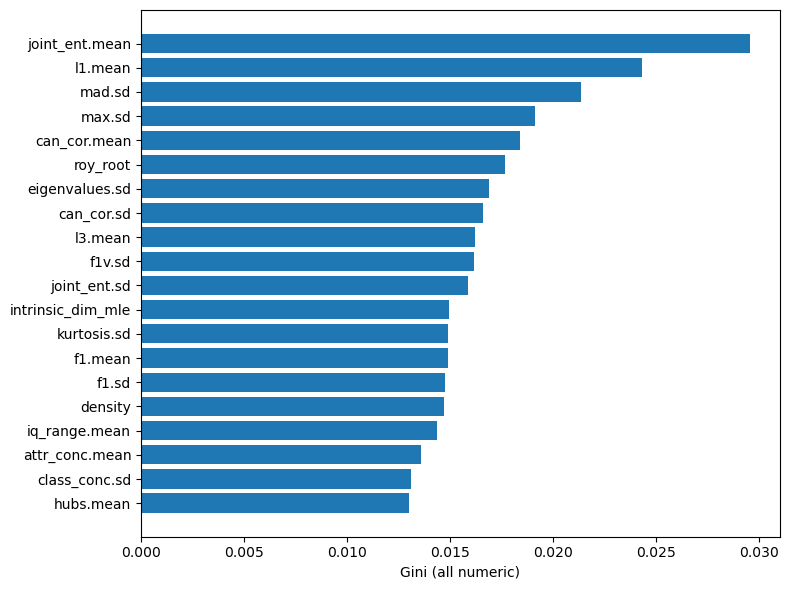

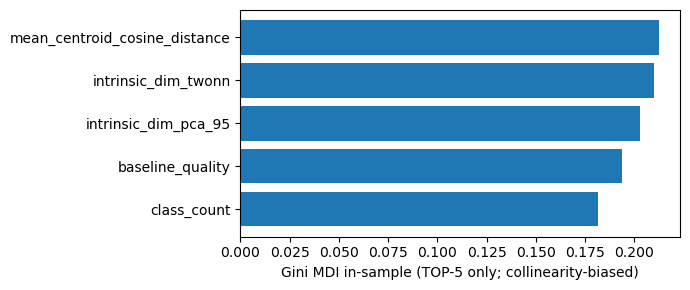

OOF permutation importance (GroupKFold test folds):
                      feature    mean    std
mean_centroid_cosine_distance -0.0244 0.0668
             baseline_quality  0.0133 0.0604
          intrinsic_dim_twonn  0.0182 0.0652
         intrinsic_dim_pca_95  0.0653 0.0468
                  class_count  0.0727 0.0675


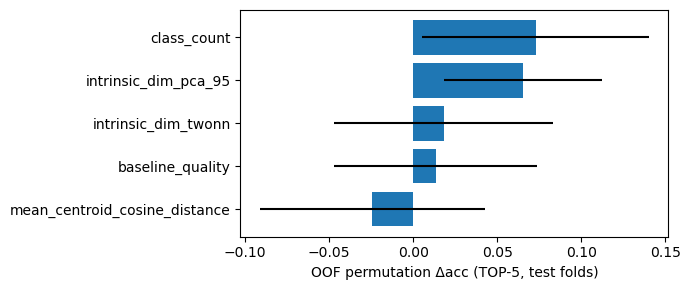

TOP-5 MI ranks:
 rank                       feature       mi
    1                   class_count 0.644190
   29          intrinsic_dim_pca_95 0.442550
   43 mean_centroid_cosine_distance 0.390086
   85           intrinsic_dim_twonn 0.252586
   93              baseline_quality 0.193600


In [3]:
X_all = matrix(df, numeric_cols)
clf_all = fit_rf(X_all, y)

imp = pd.DataFrame({"feature": numeric_cols, "gini": clf_all.feature_importances_})
imp["family"] = np.where(
    imp["feature"].isin(TOP5), "TOP-5",
    np.where(imp["feature"].isin(pymfe_cols), "PyMFE", "extra DCP"),
)
imp = imp.sort_values("gini", ascending=False)
print("Gini share TOP-5 / PyMFE:",
      f"{imp.loc[imp.family=='TOP-5','gini'].sum():.1%} / {imp.loc[imp.family=='PyMFE','gini'].sum():.1%}")
print(imp.head(12).to_string(index=False))

top_k = imp.head(20)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_k["feature"][::-1], top_k["gini"][::-1])
ax.set_xlabel("Gini (all numeric)")
fig.tight_layout()
fig.savefig(FIGURES / "gini_top20.png", bbox_inches="tight")
plt.show()

clf5 = fit_rf(matrix(df, TOP5), y)
gini5 = pd.DataFrame({"feature": TOP5, "gini": clf5.feature_importances_}).sort_values("gini")
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(gini5["feature"], gini5["gini"])
ax.set_xlabel("Gini MDI in-sample (TOP-5 only; collinearity-biased)")
fig.tight_layout()
fig.savefig(FIGURES / "gini_top5.png", bbox_inches="tight")
plt.show()

X5 = matrix(df, TOP5)
perm_mean, perm_std = oof_permutation_importance(X5, y, groups)
perm5_df = pd.DataFrame({"feature": TOP5, "mean": perm_mean, "std": perm_std}).sort_values("mean")
print("OOF permutation importance (GroupKFold test folds):")
print(perm5_df.round(4).to_string(index=False))
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(perm5_df["feature"], perm5_df["mean"], xerr=perm5_df["std"])
ax.set_xlabel("OOF permutation Δacc (TOP-5, test folds)")
fig.tight_layout()
fig.savefig(FIGURES / "perm_top5.png", bbox_inches="tight")
plt.show()

mi = mutual_info_classif(X_all, y, random_state=42)
mi_df = pd.DataFrame({"feature": numeric_cols, "mi": mi})
mi_df["family"] = np.where(
    mi_df["feature"].isin(TOP5), "TOP-5",
    np.where(mi_df["feature"].isin(pymfe_cols), "PyMFE", "extra DCP"),
)
mi_df = mi_df.sort_values("mi", ascending=False)
mi_df["rank"] = np.arange(1, len(mi_df) + 1)
print("TOP-5 MI ranks:")
print(mi_df.loc[mi_df.family == "TOP-5", ["rank", "feature", "mi"]].to_string(index=False))


## Сравнительный анализ признаков

Разбиение выборки выполняется по источнику данных. После применения порога фильтрации остаётся ~ 57 уникальных групп. При использовании 5 батчей кросс-валидации на тестовую выборку приходится около 11 источников. В таких условиях использование единственной инициализации приводит к высокой дисперсии оценок, обусловленной случайностью разбиения.

Для получения робастных метрик применяется **Repeated GroupKFold (5 разбиений × 10 инициализаций)**, что в сумме даёт 50 блоков. В итоговой таблице приведены средние значения и стандартные отклонения полных Out-of-Fold предсказаний.

Примечание: в отличие от детерминированного `GroupKFold` без перемешивания, используемого в скрипте финального обучения `train_meta_model.py` (где фиксируются Accuracy ~ 0.36, Adjacent ~ 0.79), здесь применяется Repeated-валидация. Усреднённые метрики на 10 сидах сглаживают дисперсию и ожидаются на уровне Accuracy ~ 0.43, Adjacent ~ 0.76.

Repeated GroupKFold: 5 splits × 10 seeds
57 groups, 196 rows
TOP-5            p=  5  acc=0.430±0.015  adj=0.763±0.018  (fold adj 0.762±0.091, n=50)
PyMFE            p=107  acc=0.466±0.015  adj=0.792±0.013  (fold adj 0.790±0.081, n=50)
extra DCP        p= 10  acc=0.443±0.030  adj=0.766±0.024  (fold adj 0.764±0.084, n=50)
TOP-5 + PyMFE    p=112  acc=0.466±0.024  adj=0.792±0.010  (fold adj 0.791±0.082, n=50)
all numeric      p=122  acc=0.466±0.022  adj=0.792±0.016  (fold adj 0.791±0.087, n=50)
          set   p  Accuracy  Accuracy_std  Adjacent  Adjacent_std
     Majority   0     0.316         0.000       NaN           NaN
        TOP-5   5     0.430         0.015     0.763         0.018
        PyMFE 107     0.466         0.015     0.792         0.013
    extra DCP  10     0.443         0.030     0.766         0.024
TOP-5 + PyMFE 112     0.466         0.024     0.792         0.010
  all numeric 122     0.466         0.022     0.792         0.016


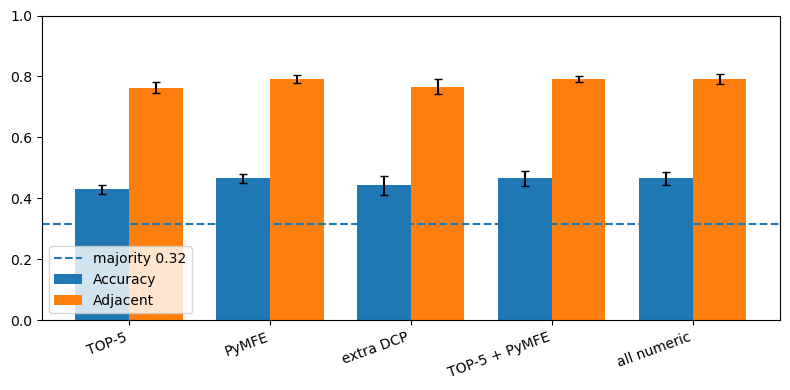

In [4]:
feature_sets = {
    "TOP-5": TOP5,
    "PyMFE": pymfe_cols,
    "extra DCP": extra_cols,
    "TOP-5 + PyMFE": TOP5 + pymfe_cols,
    "all numeric": numeric_cols,
}

n_groups = len(set(groups.tolist()))
print(f"Repeated GroupKFold: {CV_SPLITS} splits × {CV_REPEATS} seeds")
print(f"{n_groups} groups, {len(y)} rows")

rows = [{
    "set": "Majority",
    "p": 0,
    "Accuracy": majority_acc,
    "Accuracy_std": 0.0,
    "Adjacent": float("nan"),
    "Adjacent_std": float("nan"),
}]
for name, cols in feature_sets.items():
    if not cols:
        continue
    stats = repeated_oof_stats(matrix(df, cols), y, groups)
    rows.append({
        "set": name,
        "p": len(cols),
        **{k: stats[k] for k in ("Accuracy", "Accuracy_std", "Adjacent", "Adjacent_std")},
    })
    print(
        f"{name:16s} p={len(cols):3d}  "
        f"acc={stats['Accuracy']:.3f}±{stats['Accuracy_std']:.3f}  "
        f"adj={stats['Adjacent']:.3f}±{stats['Adjacent_std']:.3f}  "
        f"(fold adj {stats['fold_adj_mean']:.3f}±{stats['fold_adj_std']:.3f}, n={stats['n_folds']})"
    )

cmp = pd.DataFrame(rows)
print(cmp.round(3).to_string(index=False))
cmp.to_csv(FIGURES / "ablation_groupkfold.csv", index=False)

plot_df = cmp[cmp["set"] != "Majority"]
fig, ax = plt.subplots(figsize=(8, 4))
idx = np.arange(len(plot_df))
w = 0.38
ax.bar(idx - w / 2, plot_df["Accuracy"], w, yerr=plot_df["Accuracy_std"], capsize=3, label="Accuracy")
ax.bar(idx + w / 2, plot_df["Adjacent"], w, yerr=plot_df["Adjacent_std"], capsize=3, label="Adjacent")
ax.axhline(majority_acc, ls="--", label=f"majority {majority_acc:.2f}")
ax.set_xticks(idx)
ax.set_xticklabels(plot_df["set"], rotation=20, ha="right")
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "ablation.png", bbox_inches="tight")
plt.show()


## Итоговая оценка на объединённой выборке

На данном этапе выполняется объединение основной таблицы отбора (`feature_selection.csv`) и дополнительной выборки (`training_extra.csv`) с последующим применением порога фильтрации линейной разделимости. Итоговая мета-модель обучается именно на этом наборе данных.

При использовании 10-кратного Repeated GroupKFold усреднённые метрики составляют Accuracy ~ 0.46, Adjacent Accuracy ~ 0.76. (Для справки: одиночный детерминированный прогон в `train_meta_model.py` даёт 0.43 / 0.79).

In [5]:
combined = pd.concat([raw_sel, raw_extra], ignore_index=True, sort=False)
combined = combined.drop_duplicates(subset=[ID_COLUMN], keep="first")
combined = _drop_failed_separability_rows(combined)
if "task_family" in combined.columns:
    family_str = combined["task_family"].fillna("single").astype(str).replace(
        {"0": "single", "0.0": "single", "1": "pair", "1.0": "pair",
         "4": "tabular", "4.0": "tabular", "nan": "single"}
    )
    combined = combined[family_str.isin(["single", "pair", "sts"])]
combined = combined.dropna(subset=[TARGET_COLUMN])
combined = _assign_target_buckets(combined, TARGET_COLUMN)
combined[TOP5] = combined[TOP5].apply(pd.to_numeric, errors="coerce").fillna(0.0)

y_c = combined["target_class"].to_numpy(dtype=int)
g_c = combined[ID_COLUMN].map(_base_source_name).to_numpy()
n_g = len(set(g_c.tolist()))
stats_c = repeated_oof_stats(matrix(combined, TOP5), y_c, g_c)
maj_c = float(np.mean(y_c == int(pd.Series(y_c).mode().iloc[0])))
print(f"combined: {len(y_c)} rows, {n_g} groups")
print(
    f"TOP-5 OOF acc={stats_c['Accuracy']:.3f}±{stats_c['Accuracy_std']:.3f}  "
    f"adj={stats_c['Adjacent']:.3f}±{stats_c['Adjacent_std']:.3f}"
)
print(f"majority acc={maj_c:.3f}")
print(
    f"pooled folds: acc {stats_c['fold_acc_mean']:.3f}±{stats_c['fold_acc_std']:.3f}, "
    f"adj {stats_c['fold_adj_mean']:.3f}±{stats_c['fold_adj_std']:.3f} "
    f"(n={stats_c['n_folds']})"
)


Dropped 44 rows below the linear-separability gate: amazon counterfactual, amazon reviews multi en, anli r3, goemotions, mrpc, paws, paws-x english, qnli, qqp, rotten tomatoes (binary), rte, rucola acceptability, rugoemotions, sst-2 (binary), sst-5 (5 classes), terra (ru nli), tweeteval hate, tweeteval offensive
Bucket counts: 4=82, 8=41, 16=30, 32=18, 64=44, 128=21, 256=18
combined: 254 rows, 115 groups
TOP-5 OOF acc=0.465±0.018  adj=0.763±0.013
majority acc=0.323
pooled folds: acc 0.464±0.073, adj 0.760±0.074 (n=50)
